In [1]:
#1
import pandas as pd

df = pd.read_csv("agriculture_yield_dataset.csv")

print("Shape:", df.shape)

print("Columns:")
print(df.columns.tolist())

print(df.head(10))

Shape: (1500, 8)
Columns:
['rainfall_mm', 'temperature_c', 'fertilizer_kg', 'irrigation_hours', 'soil_ph', 'crop_type', 'soil_type', 'yield_ton_per_hectare']
   rainfall_mm  temperature_c  fertilizer_kg  irrigation_hours  soil_ph  \
0        588.6           18.6          242.4               6.5      6.5   
1        772.8           34.6          247.2              10.0      6.5   
2        970.9           36.3          168.4               7.3      6.4   
3        611.7           19.0          121.7               3.7      6.0   
4        696.1           29.6          184.6               5.1      6.1   
5        831.9           28.0          190.3               2.1      6.1   
6       1023.8           32.0          108.5               6.9      6.2   
7       1142.4           18.4          241.9               4.1      7.3   
8        810.4           36.4          164.8               9.9      6.5   
9       1085.5           29.4           89.3               8.3      5.8   

  crop_type soil

In [ ]:
#2
print(df.dtypes)

print(df.isnull().sum())

rainfall_mm              float64
temperature_c            float64
fertilizer_kg            float64
irrigation_hours         float64
soil_ph                  float64
crop_type                 object
soil_type                 object
yield_ton_per_hectare    float64
dtype: object
rainfall_mm              0
temperature_c            0
fertilizer_kg            0
irrigation_hours         0
soil_ph                  0
crop_type                0
soil_type                0
yield_ton_per_hectare    0
dtype: int64


In [2]:
#3
stats = df.describe()
print(stats)

highest_mean = stats.loc['mean'].idxmax()
print("\nFeature with highest mean:", highest_mean)

highest_std = stats.loc['std'].idxmax()
print("Feature with highest standard deviation:", highest_std)

       rainfall_mm  temperature_c  fertilizer_kg  irrigation_hours  \
count  1500.000000    1500.000000    1500.000000       1500.000000   
mean    754.054667      27.749467     148.744067          5.403267   
std     255.097216       5.758101      56.990279          2.584329   
min     300.200000      18.000000      50.300000          1.000000   
25%     536.175000      22.600000      98.600000          3.200000   
50%     761.200000      27.700000     146.850000          5.400000   
75%     964.375000      32.600000     196.575000          7.600000   
max    1200.000000      38.000000     249.900000         10.000000   

           soil_ph  yield_ton_per_hectare  
count  1500.000000            1500.000000  
mean      6.759133               5.028793  
std       0.719742               0.968282  
min       5.500000               2.090000  
25%       6.100000               4.337500  
50%       6.800000               5.010000  
75%       7.400000               5.740000  
max       8.00000

In [ ]:
#4
import plotly.express as px

px.histogram(df, x='rainfall_mm', title='Distribution of Rainfall')

Rainfall values are spread across a wide range, approximately from 300 mm to 1200 mm, indicating diverse rainfall conditions.
The distribution is fairly uniform, as the frequencies across most rainfall intervals are similar and there is no sharp peak.

In [ ]:
#histogram for temperature
px.histogram(df, x='temperature_c', title='Distribution of Temperature')

Temperature values are spread across range of 17.5 to 38.5 degrees celcius, indicating diverse conditions.
The distribution is fairly uniform, as the frequencies across most temperatures are similar and there is no sharp peak.

In [ ]:
#histogram for fertilizer
px.histogram(df, x='fertilizer_kg', title='Distribution of Fertilizer')

Fertilizer usage ranges from approximately 50 kg to 250 kg, showing a wide variation in fertilizer application.
Maximum count is of 75 to 85kg fertilizer.


In [ ]:
#histogram for yield
px.histogram(df, x='yield_ton_per_hectare', title='Distribution of Crop Yield')

Observation: The graph is approximately normal (bell shaped)

In [ ]:
#5
crop_count = df["crop_type"].value_counts()
print(crop_count)

# bar chart for crop type
fig = px.bar(
    x=crop_count.index,
    y=crop_count.values,
    labels={'x': 'Crop Type', 'y': 'Count'},
    title='Count of Each Crop Type'
)
fig.show()

# Most frequent crop
print("Most Frequent Crop:", crop_count.idxmax())

crop_type
Cotton     311
Soybean    306
Wheat      303
Rice       293
Maize      287
Name: count, dtype: int64


Most Frequent Crop: Cotton


In [ ]:
#6
soil_count = df["soil_type"].value_counts()
print(soil_count)

# count plot
fig = px.bar(
    x=soil_count.index,
    y=soil_count.values,
    labels={'x': 'Soil Type', 'y': 'Count'},
    title='Count of Each Soil Type'
)
fig.show()

# Most common soil type
print("Most Common Soil Type:", soil_count.idxmax())

soil_type
Clay     534
Sandy    492
Loamy    474
Name: count, dtype: int64


Most Common Soil Type: Clay


In [ ]:
#7
px.histogram(df, x='yield_ton_per_hectare', title='Distribution of Crop Yield',
             labels={'yield_ton_per_hectare': 'Yield (Ton per Hectare)'})


Yes, the distribution is approximately normal (bell-shaped).
Most yield values are concentrated around 5 tons per hectare.

No significant outliers are visible.
A few values occur near 2–3 and 7–8 tons per hectare which can be considered as outliers.

In [ ]:
#8
fig = px.scatter(
    df,
    x='rainfall_mm',
    y='yield_ton_per_hectare',
    title='Rainfall vs Crop Yield'
)
fig.show()

fig = px.scatter(
    df,
    x='fertilizer_kg',
    y='yield_ton_per_hectare',
    title='Fertilizer vs Crop Yield'
)
fig.show()

According to graphs Rainfall has a stronger relationship with yield produced.There is a positive relationship between rainfall and crop yield.
As rainfall increases, the yield tends to increase.

In [ ]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()

# Fits the categories and converts them to integers (e.g., 0 and 1)
df["crop_type"] = le.fit_transform(df["crop_type"])

df["soil_type"] = le.fit_transform(df["soil_type"])



                       rainfall_mm  temperature_c  fertilizer_kg  \
rainfall_mm               1.000000       0.026721       0.002558   
temperature_c             0.026721       1.000000       0.037468   
fertilizer_kg             0.002558       0.037468       1.000000   
irrigation_hours          0.010877       0.007114      -0.010497   
soil_ph                   0.006916       0.001513       0.010001   
crop_type                 0.039569       0.041556       0.027912   
soil_type                -0.007904      -0.008634       0.018753   
yield_ton_per_hectare     0.553704      -0.022559       0.278043   

                       irrigation_hours   soil_ph  crop_type  soil_type  \
rainfall_mm                    0.010877  0.006916   0.039569  -0.007904   
temperature_c                  0.007114  0.001513   0.041556  -0.008634   
fertilizer_kg                 -0.010497  0.010001   0.027912   0.018753   
irrigation_hours               1.000000  0.009307  -0.008147  -0.046006   
soil_ph     

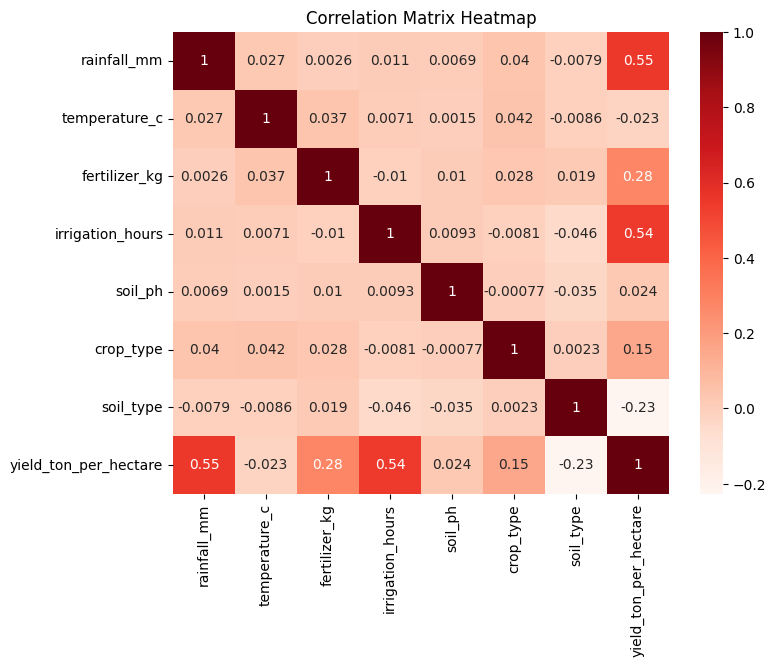


Top Correlations with Yield:
rainfall_mm         0.553704
irrigation_hours    0.542664
fertilizer_kg       0.278043
crop_type           0.154771
soil_ph             0.024412
temperature_c      -0.022559
soil_type          -0.227301
Name: yield_ton_per_hectare, dtype: float64


In [ ]:
#9
corr_matrix = df.corr()
print(corr_matrix)

import seaborn as sns
import matplotlib.pyplot as plt
plt.figure(figsize=(8,6))
sns.heatmap(df.corr(), annot=True, cmap='Reds')
plt.title("Correlation Matrix Heatmap")
plt.show()

yield_corr = df.corr()['yield_ton_per_hectare'].drop('yield_ton_per_hectare')
print("\nTop Correlations with Yield:")
print(yield_corr.sort_values(ascending=False))

In [ ]:
#10
crop_avg_yield = df.groupby('crop_type')['yield_ton_per_hectare'].mean()
print("Average Yield by Crop Type:")
print(crop_avg_yield)

soil_avg_yield = df.groupby('soil_type')['yield_ton_per_hectare'].mean()
print("\nAverage Yield by Soil Type:")
print(soil_avg_yield)

# Crop type with highest average yield
highest_crop = crop_avg_yield.idxmax()
print("\nCrop with Highest Average Yield:", highest_crop)

# Soil type with highest average yield
highest_soil = soil_avg_yield.idxmax()
print("Soil Type with Highest Average Yield:", highest_soil)

Average Yield by Crop Type:
crop_type
0    4.607299
1    4.897143
2    5.494744
3    5.173431
4    4.989472
Name: yield_ton_per_hectare, dtype: float64

Average Yield by Soil Type:
soil_type
0    5.134326
1    5.366519
2    4.588882
Name: yield_ton_per_hectare, dtype: float64

Crop with Highest Average Yield: 2
Soil Type with Highest Average Yield: 1


In [ ]:
df = pd.read_csv("agriculture_yield_dataset.csv")
categorical_cols = df.select_dtypes(include='object').columns

print(categorical_cols)

#one-hot encoding
df_encoded = pd.get_dummies(df, columns=categorical_cols, drop_first=True)
print(df_encoded.head())

print("\nFirst five rows:")
print(df_encoded.head())

Index(['crop_type', 'soil_type'], dtype='object')
   rainfall_mm  temperature_c  fertilizer_kg  irrigation_hours  soil_ph  \
0        588.6           18.6          242.4               6.5      6.5   
1        772.8           34.6          247.2              10.0      6.5   
2        970.9           36.3          168.4               7.3      6.4   
3        611.7           19.0          121.7               3.7      6.0   
4        696.1           29.6          184.6               5.1      6.1   

   yield_ton_per_hectare  crop_type_Maize  crop_type_Rice  crop_type_Soybean  \
0                   5.92             True           False              False   
1                   6.24             True           False              False   
2                   4.77            False           False              False   
3                   4.04             True           False              False   
4                   5.17            False           False              False   

   crop_type_Wheat

In [ ]:
#12
X = df_encoded.drop('yield_ton_per_hectare', axis=1)

y = df_encoded['yield_ton_per_hectare']

print("Input Features (X):")
print(X.head())

print("\nTarget Variable (y):")
print(y.head())

print("\nShape of X:", X.shape)
print("Shape of y:", y.shape)

Input Features (X):
   rainfall_mm  temperature_c  fertilizer_kg  irrigation_hours  soil_ph  \
0        588.6           18.6          242.4               6.5      6.5   
1        772.8           34.6          247.2              10.0      6.5   
2        970.9           36.3          168.4               7.3      6.4   
3        611.7           19.0          121.7               3.7      6.0   
4        696.1           29.6          184.6               5.1      6.1   

   crop_type_Maize  crop_type_Rice  crop_type_Soybean  crop_type_Wheat  \
0             True           False              False            False   
1             True           False              False            False   
2            False           False              False             True   
3             True           False              False            False   
4            False           False              False            False   

   soil_type_Loamy  soil_type_Sandy  
0             True            False  
1       